### Exploring NT Ultra-Flexible Tentacle Electrode Data - RAT rTBY34

This notebook serves to explore different preprocessing and postprocessing steps with spikeInterface using UFTE LFP data. 

***

Load data into the proper format for SpikeInterface

Create a probe for the data and match the two 

Show general stats / visualize the data quickly 

identify any regions that are extremely noisy (example beginning of buszaki data) maybe make a function that will identify these regions and gives the start and end time of these (or index) 

other than those already marked as problematic from the XML file, identify which other channels are noise (ie, waves or other type of noise (figure out what types of noise there are))

Preprocess (give possibility to explore different functions and to give stats on which is best / add any functions that could be useful given our particular data (ie not knowing the x-coord with certainty))

spike sorting, have access to different algorithms and give benchmarking results on which are good and which are less good / why 
- determine a metric 

convert data into NWB format / output to phy ? 

***
### Loading data

In [3]:
import spikeinterface as si 
import spikeinterface.preprocessing as spre
from dataLoading_utils import getXMLData
from dataAnalysis_utils import find_repetitive_channels
import numpy as np
import spikeinterface.widgets as sw
import matplotlib.pyplot as plt
from probeinterface import Probe, ProbeGroup, generate_linear_probe, generate_multi_shank, combine_probes 
from probeinterface.plotting import plot_probe

In [4]:
dat_path = r"e:\rTBY34\session5\amplifier.dat" # [60, 40, 40, 60]
xml_path = r"e:\rTBY34\session5\amplifier.xml" 

channel_ids, skippedChannels, xml_data = getXMLData(xml_path)
nBits, nChannels, samplingRate, offset, lfpSamplingRate = xml_data

print(f"Number of bits: {nBits}, Number of channels: {nChannels}, Sampling rate: {samplingRate} Hz, Offset: {offset}, LFP sampling rate: {lfpSamplingRate} Hz")

uV_per_count = 0.195 #https://intantech.com/files/Intan_RHX_user_guide.pdf

Number of bits: 16, Number of channels: 256, Sampling rate: 20000.0 Hz, Offset: 0.0, LFP sampling rate: 2000.0 Hz


### Create a Recording object

Select only channels from shank 3 ([128:192])

In [8]:
full_recording = si.read_binary(file_paths=dat_path, sampling_frequency=samplingRate, dtype=f"int{nBits}", num_channels=nChannels, channel_ids=np.arange(nChannels), is_filtered=False, gain_to_uV=uV_per_count, offset_to_uV=0.0)

shank3_channel_ids = np.array(channel_ids[128:192])
shank3_recording = full_recording.select_channels(channel_ids=shank3_channel_ids)

shank3_recording

ChannelSliceRecording: 64 channels - 20.0kHz - 1 segments - 74,015,744 samples 
                       3,700.79s (1.03 hours) - int16 dtype - 8.82 GiB

In [4]:
%matplotlib widget

traces = shank3_recording.get_traces(channel_ids=shank3_channel_ids[-10:], start_frame=0, end_frame=10000, return_in_uV=True)  
sw.plot_traces(shank3_recording, channel_ids=shank3_channel_ids[-10:], return_in_uV=True, backend="ipywidgets")


AppLayout(children=(TimeSlider(children=(Dropdown(description='Segment', options=(0,), value=0), Button(icon='…

### Create a Probe

First create a flat probe given the known geometry and model the wire bending to get the final x and y coordinates for each contact site. 

We will first work with shank 3. The flat probe has 50um between each contact site in depth 

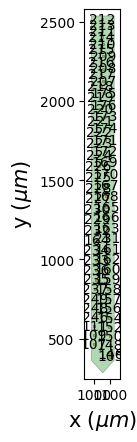

In [9]:
from probeGeom import create_flat_geom
from clean_bending_model import BundleParameters, run_from_array

# set parameters for probe geometry 
num_contact_sites = 64
y_flat_contact_dist = 40 # um 
x_flat_contact_dist = 33.3 # um (based on figure from https://www.nature.com/articles/s41467-024-49226-9#Sec7)
final_probe_width = 80 # um
base_length = 10000.0  # choose something comfortably larger than the max y offset

# create the flat geometry for the electrode tips and the base of the probe
electrode_tips = create_flat_geom(num_contact_sites, x_flat_contact_dist, y_flat_contact_dist)
electrode_base = np.column_stack((electrode_tips[:,0], np.ones(num_contact_sites)*base_length))

# model the bundling of the probe and get the new coordinates for the electrode tips and ends of the probe
params = BundleParameters(
    first_bend_distance=150.0,
    max_bend_angle_deg=45.0,
    bundle_ratio=0.05,
    first_radius=300.0,
    second_radius=300.0,
)

result = run_from_array(electrode_base, electrode_tips,params=params, make_plot=False) # positions are in result.ends and result.tips

# create the SpikeInterface probe object and plot it
probe = Probe(ndim=2, si_units='um')
probe.set_contacts(positions=result.ends, shapes=np.array(['square'] * num_contact_sites), shape_params={"width": 13})
# set the contact IDs for each site 
probe.set_device_channel_indices(np.arange(num_contact_sites))
probe.set_contact_ids(shank3_channel_ids)
probe.create_auto_shape()

# plot the probe geometry to check it looks correct
# plot_probe(probe, with_contact_id=True, with_device_index=True)
    
# link the probe geometry to our recording object 
shank3_recording.set_probe(probe, in_place=True)

sw.plot_probe_map(shank3_recording, with_channel_ids=True, backend="matplotlib")

# Preprocessing: 
### Remove Noisy Channels

First those labeled in the XML file and next those detected by SpikeInterface 

Shank 3 channels to skip: [105 107 109 111 146 148 150 152 154 156 157 158 159 160 161 162 164 231
 233 234 235 236 237 246 248 249]


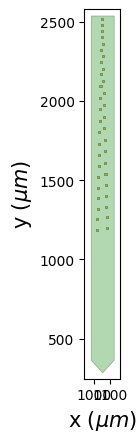

In [10]:
# STEP 1: remove channels already identified as bad in the xml file
shank3_skipped_channels = np.intersect1d(shank3_channel_ids, skippedChannels)
print(f"Shank 3 channels to skip: {shank3_skipped_channels}")  


clean_recording = shank3_recording.remove_channels(shank3_skipped_channels)
clean_channel_ids = clean_recording.get_channel_ids()
sw.plot_probe_map(clean_recording)

IBL-defined Bad channel IDs: [219 217]


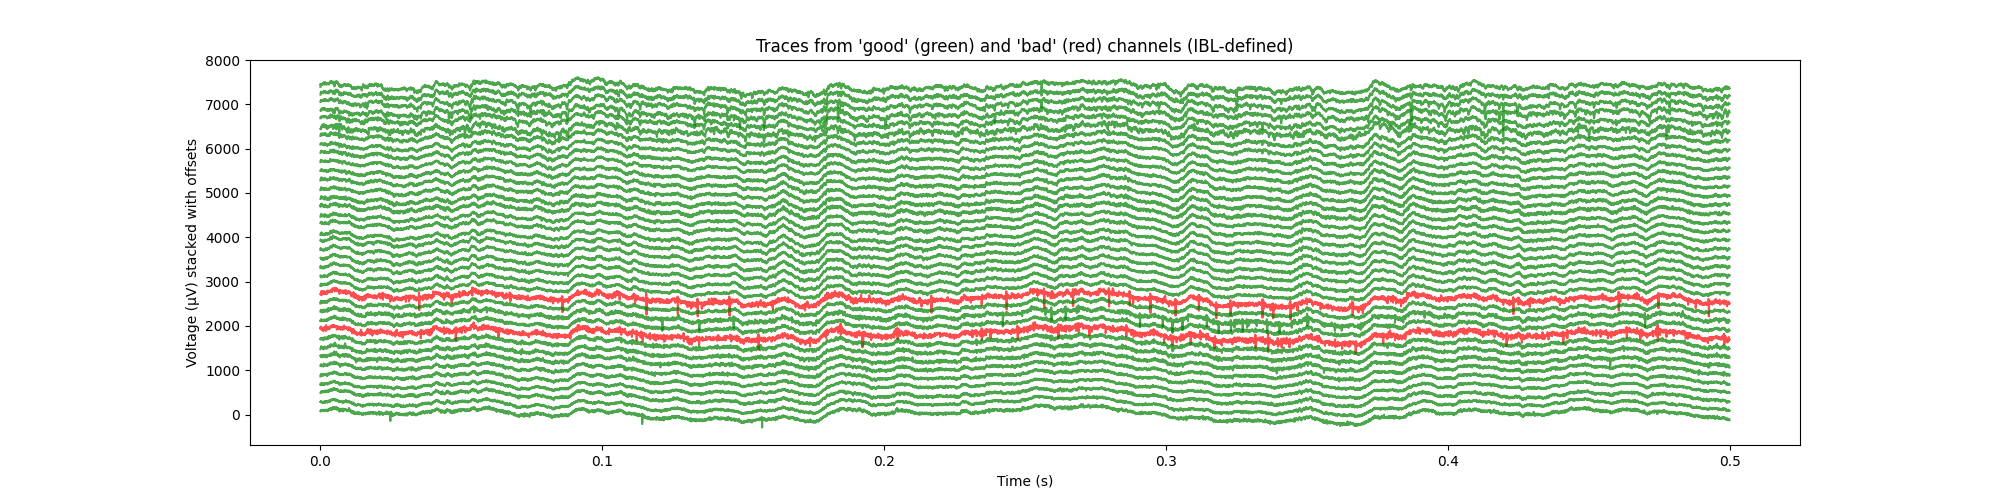

In [7]:
# STEP 2: detect bad channels as defined by IBL 

bad_channel_ids, channel_labels = spre.detect_bad_channels(clean_recording, 
                         method='coherence+psd', 
                         std_mad_threshold=5, 
                         psd_hf_threshold=0.02,
                         dead_channel_threshold=-0.5, 
                         noisy_channel_threshold= 1.0, 
                         outside_channel_threshold=-0.75, 
                         outside_channels_location= 'top', # Literal['top', 'bottom', 'both']
                         n_neighbors = 11, 
                         nyquist_threshold =  0.8, 
                         direction = 'y', # Literal['x', 'y', 'z'] 
                         chunk_duration_s = 0.3, 
                         num_random_chunks = 100, 
                         welch_window_ms = 10.0, 
                         highpass_filter_cutoff = 300, 
                         neighborhood_r2_threshold = 0.9,
                         neighborhood_r2_radius_um = 30.0, 
                         seed = None, 
                         channel_filters = None)

print(f"IBL-defined Bad channel IDs: {bad_channel_ids}")

# plot trace examples with 'good' and 'bad' channels to see if they look different
traces = clean_recording.get_traces(channel_ids=clean_channel_ids, start_frame=0, end_frame=10000, return_in_uV=True)
offsets = np.arange(traces.shape[1]) * 200
offsets = offsets[::-1]
t = np.arange(traces.shape[0]) / (samplingRate) # Time vector in seconds
plt.figure(figsize=(20, 5))
for i, id in enumerate(clean_channel_ids):
    color = 'red' if id in bad_channel_ids else 'green'
    plt.plot(t, traces[:, i] + offsets[i], alpha=0.7, color=color)

plt.xlabel("Time (s)")
plt.ylabel("Voltage (µV) stacked with offsets")
plt.title("Traces from 'good' (green) and 'bad' (red) channels (IBL-defined)")
plt.show()

### Detecting artifact periods

In [ ]:
art_periods = spre.detect_artifact_periods(clean_recording, 'envelope')
# method: Literal['envelope', 'saturation'] 

In [ ]:
print(f"Detected artifact periods (in samples): {art_periods}")

***

### Preprocessing

Beware of which steps do and do not use the probe geometry. 

Geometry agnostic: bandpass_filter, highpass_filter, notch_filter, generic filter, center, zscore, scale, clip, astype, resample, rectify, phase_shift, whiten

Geometry-dependent: CAR, average_across_direction, directional_derivative, highpass_spatial_filter, depth_order, compute_motion, correction_motion

Kilosort4 performs the following preprocessing steps:
1. remove mean across channels 
2. CAR
3. temporal filtering per-channel filtering high pass filter at 300Hz 
4. local channel whitening (uses local 32 channels) 
5. drift estimation and correction 

In [ ]:
o = spre.center(recording, mode='median', dtype='float32')

In [ ]:
si.preprocessing.whiten(recording, dtype=None, apply_mean=False, regularize=False, regularize_kwargs=None, mode='global', radius_um=100.0, int_scale=None, eps=None, W=None, M=None, **random_chunk_kwargs)
si.preprocessing.bandpass_filter(recording, freq_min=300.0, freq_max=6000.0, margin_ms='auto', dtype=None, ignore_low_freq_error=False, _skip_margin_warning_for_old_version=False, **filter_kwargs)


In [ ]:

spikeinterface.preprocessing.common_reference(recording: BaseRecording, reference: Literal['global', 'single', 'local'] = 'global', operator: Literal['median', 'average'] = 'median', groups: list | None = None, ref_channel_ids: list | str | int | None = None, local_radius: tuple[float, float] = (30.0, 55.0), min_local_neighbors: int = 5, dtype: str | dtype | None = None)
spikeinterface.preprocessing.compute_motion(recording: BaseRecording, preset: Literal['dredge', 'medicine', 'dredge_fast', 'nonrigid_accurate', 'nonrigid_fast_and_accurate', 'rigid_fast', 'kilosort_like'] = 'dredge_fast', detect_kwargs: dict = {}, select_kwargs: dict = {}, localize_peaks_kwargs: dict = {}, estimate_motion_kwargs: dict = {}, output_motion_info: bool = False, folder: str | Path | None = None, overwrite: bool = False, raise_error: bool = True, **job_kwargs)→ dict

spikeinterface.preprocessing.average_across_direction(parent_recording: BaseRecording, direction: str = 'y', dtype='float32')
spikeinterface.preprocessing.correct_motion(recording: BaseRecording, preset: Literal['dredge', 'medicine', 'dredge_fast', 'nonrigid_accurate', 'nonrigid_fast_and_accurate', 'rigid_fast', 'kilosort_like'] = 'dredge_fast', folder: str | Path | None = None, output_motion: bool = False, output_motion_info: bool = False, overwrite: bool = False, detect_kwargs: dict = {}, select_kwargs: dict = {}, localize_peaks_kwargs: dict = {}, estimate_motion_kwargs: dict = {}, interpolate_motion_kwargs: dict = {}, **job_kwargs)
spikeinterface.preprocessing.filter(recording, band=(300.0, 6000.0), btype='bandpass', filter_order=5, ftype='butter', filter_mode='sos', margin_ms=None, add_reflect_padding=False, coeff=None, dtype=None, direction='forward-backward')


In [ ]:
w_ts = sw.plot_traces(recording, channel_ids=channel_ids[:10])

# Spike sorting

In [8]:
from spikeinterface.sorters import run_sorter, get_default_sorter_params, get_sorter_params_description

params = get_default_sorter_params('kilosort4')
print("Parameters:\n", params)

descriptions = get_sorter_params_description('kilosort4')
print("Descriptions:\n", descriptions)


Parameters:
 {'batch_size': 60000, 'nblocks': 1, 'Th_universal': 9, 'Th_learned': 8, 'nt': 61, 'shift': None, 'scale': None, 'batch_downsampling': 1, 'artifact_threshold': inf, 'nskip': 25, 'whitening_range': 32, 'highpass_cutoff': 300, 'binning_depth': 5, 'sig_interp': 20, 'drift_smoothing': [0.5, 0.5, 0.5], 'nt0min': None, 'dmin': None, 'dminx': 32, 'min_template_size': 10, 'template_sizes': 5, 'nearest_chans': 10, 'nearest_templates': 100, 'max_channel_distance': 32, 'max_peels': 100, 'templates_from_data': True, 'n_templates': 6, 'n_pcs': 6, 'Th_single_ch': 6, 'acg_threshold': 0.2, 'ccg_threshold': 0.25, 'cluster_neighbors': 10, 'cluster_downsampling': 20, 'max_cluster_subset': 25000, 'x_centers': None, 'cluster_init_seed': 5, 'duplicate_spike_ms': 0.25, 'position_limit': 100, 'do_CAR': True, 'invert_sign': False, 'save_extra_vars': False, 'save_preprocessed_copy': False, 'torch_device': 'auto', 'bad_channels': None, 'clear_cache': False, 'do_correction': True, 'skip_kilosort_prepr

In [9]:
KS4_params = {
 'batch_size': 40000,
 'dminx': 10,
 'do_CAR': True,
 'do_correction': False, # False = don't do drift correction
 'max_threads_per_worker': 1,
 'max_channel_distance': 50,
 'n_jobs': 1,
 'nblocks': 0,
 'nearest_chans': 10,
 'nearest_templates': 100,
 'nt': 41,
 'pool_engine': 'process',
 'progress_bar': True,
 'scale': uV_per_count, # set to make sure the traces are +- 100 as desired by kilosort  
 'skip_kilosort_preprocessing': False,
 'torch_device': 'cuda'}

sorting_KS4 = run_sorter(sorter_name='kilosort4', recording=clean_recording, folder='SI_SortingResults/KS4_April_22_2026', docker_image="ks4-blackwell-cu128", verbose=True,**KS4_params)
                         
                         

installation_mode='auto' switching to installation_mode: 'dev'
Starting container
Installing spikeinterface with folder in container
Running kilosort4 sorter inside ks4-blackwell-cu128
Stopping container


C:\Users\social\Desktop\temp_Brune\spikeinterface\spikeinterface\src\spikeinterface\core\base.py:1149: UserWarning: Versions are not the same. This might lead to compatibility errors. Using spikeinterface==0.104.1 is recommended
  warnings.warn(


The following data is created as an output from the run_sorter function w/ Kilsort4:



***
***

Current questions: 
- distances between contact sites for our flexible electrodes are not constant
- probes are not inserted vertically so they have a z component as well, does this make a difference
- the xc are all identical as we assume contact sites to be about stacked on the vertical axis. is this a valid assumption 

***

***

**consider using the read_binary_folder function to concatinate multiple sessions together

*** 
## Analyzing Sorting Results

In [ ]:
from spikeinterface.extractors import read_kilosort_as_analyzer

output_path = 'SI_SortingResults/KS4_April_22_2026/sorter_output'

sorting_analyzer = read_kilosort_as_analyzer(output_path, gain_to_uV=uV_per_count, offset_to_uV=0.0)
sorting_analyzer.set_temporary_recording(clean_recording)

job_kwargs = dict(n_jobs=-1, progress_bar=True, chunk_duration="1s")

sorting_analyzer.compute("random_spikes", method="uniform", max_spikes_per_unit=500)
sorting_analyzer.compute("waveforms", **job_kwargs)
sorting_analyzer.compute("templates", **job_kwargs)
sorting_analyzer.compute("noise_levels")
sorting_analyzer.compute("unit_locations", method="monopolar_triangulation")
sorting_analyzer.compute("isi_histograms")
sorting_analyzer.compute("correlograms", window_ms=100, bin_ms=5.)
sorting_analyzer.compute("principal_components", n_components=3, mode='by_channel_global', whiten=True, **job_kwargs)
sorting_analyzer.compute("quality_metrics", metric_names=["snr", "firing_rate"])
sorting_analyzer.compute("template_similarity")
sorting_analyzer.compute("spike_amplitudes", **job_kwargs)

ValueError: Recordings do not match in the following attributes: ['channel_ids', 'num_samples', 'dtype']

Note that if you have access to the raw recording, you can attach it to the analyzer, and re-compute extensions from the raw data. E.g.

from spikeinterface.extractors import read_kilosort_as_analyzer
import spikeinterface.extractors as se
import spikeinterface.extractors as spre

recording = se.read_openephys('path/to/recording')

preprocessed_recording = spre.bandpass_filter(spre.common_reference(recording))

sorting_analyzer = read_kilosort_as_analyzer('path/to/output')
sorting_analyzer.set_temporary_recording(preprocessed_recording)

sorting_analyzer.compute({
    "spike_locations": {},
    "spike_amplitudes": {},
    "unit_locations": {},
    "correlograms": {},
    "template_similarity": {},
    "isi_histograms": {},
    "template_metrics": {"include_multi_channel_metrics": True},
    "quality_metrics": {},
})
This will take longer since you are dealing with the raw recording, but you do have a lot of control over how to compute the extensions.



In [6]:
sw.plot_sorting_summary(sorting_analyzer, backend="spikeinterface_gui")

Exception: The correlograms sorting analyzer extension is required for this widget. Run the `sorting_analyzer.compute('correlograms', ...)` to compute it.
The spike_amplitudes sorting analyzer extension is required for this widget. Run the `sorting_analyzer.compute('spike_amplitudes', ...)` to compute it.
The unit_locations sorting analyzer extension is required for this widget. Run the `sorting_analyzer.compute('unit_locations', ...)` to compute it.
The template_similarity sorting analyzer extension is required for this widget. Run the `sorting_analyzer.compute('template_similarity', ...)` to compute it.
